# Демо 3. Тяжёлая точка в круглой трубе: упругий удар и хаос

*Источник:* П.А. Кручинин. Об освоении пакета MATLAB с использованием практических задач. Здесь задача переведена на Python.

## Постановка задачи

Материальная точка (шарик) брошена в горизонтальную круглую трубу единичного радиуса в поле тяжести с ускорением $\vec a$. Между ударами точка движется по параболе:
$$
\vec r(t) = \vec r_+ + \vec v_+ t + \vec a\,\frac{t^2}{2}, \qquad \vec v(t) = \vec v_+ + \vec a\, t,
$$
где $\vec r_+$, $\vec v_+$ — положение и скорость сразу после отскока. Момент следующего удара — наименьший положительный корень уравнения $|\vec r(t)|^2 = 1$. Так как $|\vec r_+| = 1$, после деления на $t$ получается кубическое уравнение
$$
\frac{|\vec a|^2}{4}\,t^3 + (\vec v_+\cdot\vec a)\,t^2 + \bigl(|\vec v_+|^2 + \vec r_+\cdot\vec a\bigr)\,t + 2\,\vec r_+\cdot\vec v_+ = 0 .
$$
При абсолютно упругом ударе нормальная составляющая скорости меняет знак:
$$
\vec v_+ = \vec v_- - 2(\vec v_-\cdot\vec r_-)\,\vec r_- .
$$

**Что отрабатываем:** корни полинома (`np.roots`), отбор вещественных положительных корней, сигнализацию об ошибках исключениями (`raise`), визуализацию. Попутно знакомимся с динамическими системами, поведение которых может быть хаотическим.

*Замечание к исходному тексту.* Коэффициенты уравнения здесь выведены для произвольного $\vec a$. В MATLAB-программе статьи использовалось $\vec a = (0, -1)$, и тогда коэффициенты совпадают с программными (после умножения на 4).

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def billiard(alpha, vt, vn, n=100, acc=(0.0, -1.0), npts=100, tol=1e-9):
    """
    Траектория точки в круглой трубе с упругими отскоками.

    alpha  -- угол точки первого отскока, отсчитываемый от вертикали;
    vt, vn -- касательная и нормальная составляющие начальной скорости;
    n      -- число отскоков; acc -- ускорение силы тяжести;
    npts   -- число точек на каждом участке между ударами.
    Возвращает массив координат формы (n * npts, 2).
    """
    acc = np.asarray(acc, dtype=float)
    xp = np.array([np.cos(alpha), -np.sin(alpha)])
    vp = np.array([vn * np.cos(alpha) - vt * np.sin(alpha),
                   -vn * np.sin(alpha) + vt * np.cos(alpha)])
    path = []
    for i in range(n):
        # коэффициенты кубического уравнения для момента следующего удара
        c = [acc @ acc / 4, vp @ acc, vp @ vp + xp @ acc, 2 * xp @ vp]
        r = np.roots(c)
        # вещественные положительные корни; мнимую часть сравниваем с нулём с допуском
        good = (np.abs(r.imag) < tol) & (r.real > tol)
        if not good.any():
            raise ValueError(f'отскок {i}: у уравнения нет положительных вещественных корней')
        tau = r.real[good].min()

        t = np.linspace(tau / npts, tau, npts)[:, None]
        path.append(xp + vp * t + acc * t**2 / 2)

        vm = vp + acc * tau                       # скорость перед ударом
        xm = xp + vp * tau + acc * tau**2 / 2     # точка удара
        if abs(np.linalg.norm(xm) - 1) > 1e-6:
            raise ValueError(f'отскок {i}: точка удара не лежит на окружности')
        xp = xm
        vp = vm - 2 * (vm @ xm) * xm              # упругий удар
    return np.vstack(path)


def show(path, title):
    th = np.linspace(0, 2 * np.pi, 400)
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.plot(np.cos(th), np.sin(th), 'k')          # труба
    ax.plot(path[:, 0], path[:, 1], lw=0.6)
    ax.set_aspect('equal')
    ax.set_title(title)
    plt.show()

## Почти периодическое движение

Начальные условия из малой окрестности устойчивой циклической траектории: $\alpha = \pi/6$, $v_t = 1$, $v_n = 0.1$.

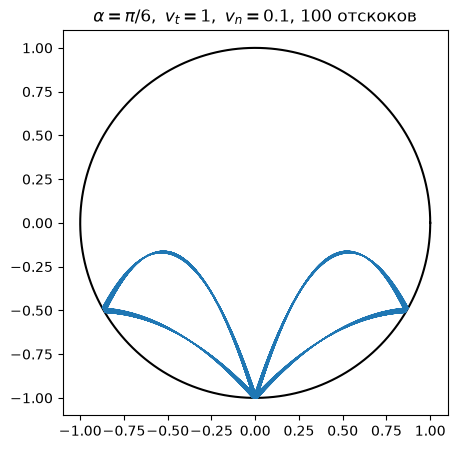

In [2]:
show(billiard(np.pi / 6, vt=1.0, vn=0.1, n=100),
     r'$\alpha=\pi/6,\ v_t=1,\ v_n=0.1$, 100 отскоков')

## Хаотическое движение

Небольшое изменение нормальной скорости ($v_n = 0.15$) даёт хаотическую траекторию. С ростом числа отскоков траектории заполняют всю область, допустимую уровнем энергии.

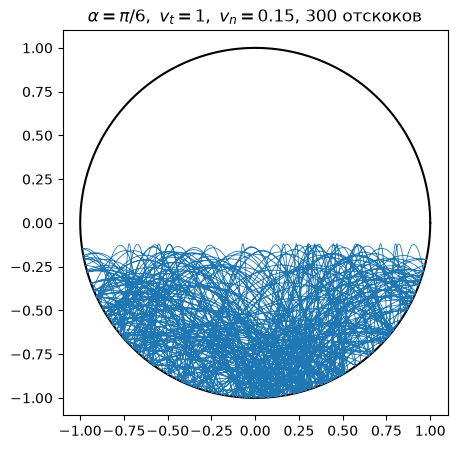

In [3]:
show(billiard(np.pi / 6, vt=1.0, vn=0.15, n=300),
     r'$\alpha=\pi/6,\ v_t=1,\ v_n=0.15$, 300 отскоков')

## Ввод данных

В MATLAB-версии начальные условия вводились в диалоговом окне `inputdlg`. В ноутбуке естественнее менять аргументы функции. Для интерактивного подбора параметров можно использовать ползунки `ipywidgets` (нужен пакет `ipywidgets`):

```python
from ipywidgets import interact, FloatSlider, IntSlider

interact(lambda vn, n: show(billiard(np.pi / 6, 1.0, vn, n), f'vn = {vn}'),
         vn=FloatSlider(min=0.0, max=0.3, step=0.01, value=0.1),
         n=IntSlider(min=10, max=500, step=10, value=100))
```

**Что попробовать:**
- найдите начальные условия, при которых функция выбрасывает исключение, и объясните его причину;
- решите ту же задачу через `solve_ivp` с событием $|\vec r|^2 - 1 = 0$ (см. главу об ОДУ) и сравните точность и время счёта.